# DA-04 Outbound Destination Runtime Validation

기존 법령·Outbound Contract의 Requirement → Field → Source → Transform →
Destination → Missing Action을 Runtime 관점에서 검증한다.
규제를 새로 수집하거나 재판단하지 않으며 결론은 저장소의 실제 계약·표본 계산에서 도출한다.

DA-00 Master → DA-01 Execution Result 분리 → DA-02 Exact → DA-03 Trace Binding
→ DA-04 Destination별 외부화. DA-05 사용자 작업은 이 분석의 입력/수정 범위가 아니다.

## 기존 Evidence와 중복 방지

PR #11은 규제 baseline, #12는 schema gap, #13/foundation 04는 outbound 설계를 작성했다.
PR #14/foundation 05는 책임 경계를 보정했고 #15/#16은 vNext와 Common Runtime을 정합화했다.
#19는 DA-00/01, #20은 DA-02, #21은 현재 DA-03 Evidence다.
PR 본문 및 현재 파일을 검토했으며 foundation 04의 재작성/복제가 아니다.
기존 contract에 실제 Master 컬럼 가용성, 목적지별 Field 감소, 악성 fixture 탐지를 추가한다.

CSV는 법적 lineage·기존 source mapping의 근거이고 vNext가 현재 runtime 규칙의 권위다.
특히 CSV의 boolean exact/변환/목적지/누락 action을 보정된 vNext에 덮어씌우지 않는다.
기존 법적 REVIEW_REQUIRED/candidate 문구는 그대로 GAP으로 유지한다.

## 검증 질문 Q1~Q8

1. Q1: Requirement → Field → Source → Transform → Destination → Missing Action이 연결되는가?
2. Q2: 현재 contract의 Destination별 필요한 Field 집합은 서로 다른가?
3. Q3: Ethereum에서 확보 가능한 Field와 upstream/external 의존 Field는 무엇인가?
4. Q4: 필수 Field를 유지하면서 목적지에 불필요한 Field를 줄일 수 있는가?
5. Q5: NOT_EXTERNALIZED/OMIT/Internal-only leakage를 validator가 탐지하는가?
6. Q6: EXACT_REQUIRED에 손실성 transform을 연결하는 모순이 있는가?
7. Q7: POST_EXECUTION-only Field가 PRE_EXECUTION에 혼입되는가?
8. Q8: Provider schema·외부 입력 dependency 중 확정할 수 없는 CONTRACT_GAP은 무엇인가?

In [1]:
# 01. Repository-relative source와 재현 모듈 로드
import importlib
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from matplotlib import font_manager

ROOT = next(
    p for p in [Path.cwd(), *Path.cwd().parents]
    if (p / '03_digital_asset/src/da_04_outbound_destination.py').is_file()
)
sys.path.insert(0, str(ROOT / '03_digital_asset/src'))
da04 = importlib.import_module('da_04_outbound_destination')

result = da04.analyze(ROOT)

## 데이터 및 Contract Provenance

Master는 실제 관측 표본이며 운영 Transaction Source가 아니다.
분석 함수는 원본 CSV를 문자열로 읽고 `value_lossless`만 atomic amount로 사용한다.
출력된 경로·SHA-256을 Artifact에도 기록한다. Master는 raw bytes, Git text source는
CRLF→LF 정규화 bytes, DA-04 Notebook은 code cell source hash를 사용한다.
Notebook 출력의 자기참조 hash 순환을 피하며 테스트에서 출력·Artifact를 별도로 대조한다.
원천 BigQuery/DA-02 ground truth를 다시 조회하지 않는다.

In [2]:
# 02. Provenance / actual sample size
display(pd.DataFrame({'path': [p.as_posix() for p in da04.SOURCES]}))
display(pd.DataFrame([result['summary']]).T.rename(columns={0: 'observed'}))

,path
0,03_digital_asset/data/processed/da_master_tran...
1,03_digital_asset/data/processed/regulatory_out...
2,03_digital_asset/data/processed/outbound_requi...
3,03_digital_asset/artifacts/outbound_design_vNe...
4,03_digital_asset/artifacts/outbound_design_vNe...
5,03_digital_asset/artifacts/outbound_design_vNe...
6,03_digital_asset/artifacts/outbound_design_vNe...
7,03_digital_asset/notebooks/foundation/01_crypt...
8,03_digital_asset/notebooks/foundation/04_regul...
9,03_digital_asset/notebooks/foundation/05_fpg_c...


,observed
sample_rows,73410
unique_transaction_hashes,73410
missing_to_address,46
amount_representation_valid_count,73410
requirement_count,18
destination_count,6
field_count,12
normalized_row_count,35
safely_mapped_onchain_field_count,5
legacy_onchain_candidate_count,6


## 전처리 및 lineage

requirement_id를 1:1 join한 후 vNext destination list를 explode한다.
Field 이름은 현재 contract를 보존한다. CSV의 pipe-separated legacy destination과
transform도 비교표에 남긴다. vNext의 수정은 분석자가 새로 만든 규제 결론이 아니다.
문자열 연결 완전성과 법적/운영 의미의 완전성은 별도다.

In [3]:
# 03. Requirement → Source → Destination → Missing Action
profile_rows = pd.DataFrame(result['normalized_requirements'])
display(profile_rows)
display(pd.DataFrame(result['legacy_to_vnext']))

,requirement_id,required_field,regulation_name,article,obligation_id,legal_basis_reference,evidence_type,legal_note,source_system,source_type,...,mandatory_level,required_exact,on_missing_action,runtime_phase,externalizable,contract_gap,legacy_destination,legacy_transform,legacy_required_exact,legacy_on_missing
0,OR-DA-001,counterparty_vasp,Act on Reporting and Using Specified Financial...,Article 2,DA-OBL-001,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,Official law portal; current law page observed...,VASP_DIRECTORY_OR_PROVIDER|TRAVEL_RULE_PROVIDER,UPSTREAM_PRODUCED_DATA,...,MANDATORY,FORMAT_TRANSFORM_ALLOWED,REVIEW,PRE_EXECUTION,True,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]",TRAVEL_RULE_PROVIDER|EXTERNAL_VASP|INTERNAL_AU...,MAP_TO_EXTERNAL_SCHEMA|SPLIT_INTERNAL_EXTERNAL,TRUE,REVIEW
1,OR-DA-001,counterparty_vasp,Act on Reporting and Using Specified Financial...,Article 2,DA-OBL-001,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,Official law portal; current law page observed...,VASP_DIRECTORY_OR_PROVIDER|TRAVEL_RULE_PROVIDER,UPSTREAM_PRODUCED_DATA,...,MANDATORY,FORMAT_TRANSFORM_ALLOWED,REVIEW,PRE_EXECUTION,False,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]",TRAVEL_RULE_PROVIDER|EXTERNAL_VASP|INTERNAL_AU...,MAP_TO_EXTERNAL_SCHEMA|SPLIT_INTERNAL_EXTERNAL,TRUE,REVIEW
2,OR-DA-002,kyc_status,Act on Reporting and Using Specified Financial...,Article 5-2,DA-OBL-002,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,FPG checks returned status only; KYC execution...,KYC_AML_SYSTEM,UPSTREAM_PRODUCED_DATA,...,MANDATORY,INTERNAL_ONLY,REVIEW,PRE_EXECUTION,False,[UPSTREAM_INPUT],NOT_EXTERNALIZED|INTERNAL_AUDIT_ONLY,OMIT,TRUE,REVIEW
3,OR-DA-002,kyc_status,Act on Reporting and Using Specified Financial...,Article 5-2,DA-OBL-002,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,FPG checks returned status only; KYC execution...,KYC_AML_SYSTEM,UPSTREAM_PRODUCED_DATA,...,MANDATORY,INTERNAL_ONLY,REVIEW,PRE_EXECUTION,False,[UPSTREAM_INPUT],NOT_EXTERNALIZED|INTERNAL_AUDIT_ONLY,OMIT,TRUE,REVIEW
4,OR-DA-003,kyc_status,Act on Reporting and Using Specified Financial...,Article 5-3,DA-OBL-003,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,Legal basis is represented as candidate contro...,KYC_AML_SYSTEM,UPSTREAM_PRODUCED_DATA,...,MANDATORY,INTERNAL_ONLY,REVIEW,PRE_EXECUTION,False,"[LEGAL_REVIEW, UPSTREAM_INPUT]",NOT_EXTERNALIZED|INTERNAL_AUDIT_ONLY,OMIT,TRUE,BLOCK
5,OR-DA-003,kyc_status,Act on Reporting and Using Specified Financial...,Article 5-3,DA-OBL-003,LAW_GO_KR::Act on Reporting and Using Specifie...,LEGAL_REQUIREMENT,Legal basis is represented as candidate contro...,KYC_AML_SYSTEM,UPSTREAM_PRODUCED_DATA,...,MANDATORY,INTERNAL_ONLY,REVIEW,PRE_EXECUTION,False,"[LEGAL_REVIEW, UPSTREAM_INPUT]",NOT_EXTERNALIZED|INTERNAL_AUDIT_ONLY,OMIT,TRUE,BLOCK
6,OR-DA-004,originator_identity,Enforcement Decree of Act on Reporting and Usi...,Article 10-10,DA-OBL-004,LAW_GO_KR::Enforcement Decree of Act on Report...,LEGAL_REQUIREMENT,Identity itself is not on-chain; FPG requires ...,INTERNAL_CUSTOMER_MASTER,UPSTREAM_PRODUCED_DATA,...,MANDATORY,MINIMIZATION_ALLOWED,REVIEW,PRE_EXECUTION,True,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]",TRAVEL_RULE_PROVIDER|EXTERNAL_VASP,MINIMIZE|MAP_TO_EXTERNAL_SCHEMA,TRUE,REVIEW
7,OR-DA-004,originator_identity,Enforcement Decree of Act on Reporting and Usi...,Article 10-10,DA-OBL-004,LAW_GO_KR::Enforcement Decree of Act on Report...,LEGAL_REQUIREMENT,Identity itself is not on-chain; FPG requires ...,INTERNAL_CUSTOMER_MASTER,UPSTREAM_PRODUCED_DATA,...,MANDATORY,MINIMIZATION_ALLOWED,REVIEW,PRE_EXECUTION,True,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]",TRAVEL_RULE_PROVIDER|EXTERNAL_VASP,MINIMIZE|MAP_TO_EXTERNAL_SCHEMA,TRUE,REVIEW
8,OR-DA-005,beneficiary_identity,Enforcement Decree of Act on Reporting and Usi...,Article 10-10,DA-OBL-005,LAW_GO_KR::Enforcement Decree of Act on Report...,LEGAL_REQUIREMENT,Identity itself is not on-chain; FPG requires ...,INTERNAL_CUSTOMER_MA

,requirement_id,changes
0,OR-DA-001,{'destination': {'legacy_csv': ['EXTERNAL_VASP...
1,OR-DA-002,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
2,OR-DA-003,"{'on_missing': {'legacy_csv': 'BLOCK', 'vnext_..."
3,OR-DA-004,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
4,OR-DA-005,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
5,OR-DA-006,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
6,OR-DA-007,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
7,OR-DA-008,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
8,OR-DA-009,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."
9,OR-DA-010,"{'exact_class': {'legacy_csv': 'TRUE', 'vnext_..."


## 기술통계 및 Availability

Field-level 분모는 unique Required Field다. ONCHAIN 후보는 legacy execution mapping,
안전 매핑은 실제 컬럼과 vNext 의미가 일치하는 항목으로 구분한다.
transaction_id의 legacy hash mapping은 PRE_EXECUTION 승인 Trace ID를 대체할 수 없다.
`receipt_status`는 관측되지만 provider execution_status/finality enum으로 자동 매핑하지 않는다.
asset은 native ETH 관측만으로 승인 자산·Token scale을 확정할 수 없다(DA-03 정합성).

off-chain 비율은 실행 전 upstream/approval Trace/asset context 의존 Field 비율이다.
POST 비율은 vNext phase 기준이다. source와 phase는 서로 다른 축이므로 비율 합계가
100%일 필요가 없다. 표본 컬럼 값의 존재는 승인·전송 가능성이나 원천 정확성 인증이 아니다.

In [4]:
# 04. Destination 집계와 transaction-level 실제 값 가용성
destination_summary = pd.DataFrame(result['destination_summary'])
availability = pd.DataFrame(result['field_availability'])
display(destination_summary)
display(availability)

,destination,requirement_count,unique_required_field_count,onchain_field_count,offchain_dependency_count,post_execution_dependency_count,exact_required_count,omit_internal_only_count,contract_gap_count
0,BLOCKCHAIN_EXECUTION_SYSTEM,4,4,3,1,0,4,0,1
1,EXTERNAL_VASP,4,2,0,2,0,0,0,4
2,INTERNAL_AUDIT_ONLY,7,4,1,2,2,2,1,6
3,INTERNAL_RECONCILIATION_ONLY,10,7,5,1,3,7,0,5
4,NOT_EXTERNALIZED,2,1,0,1,0,0,1,2
5,TRAVEL_RULE_PROVIDER,8,5,0,5,0,2,0,8


,required_field,availability_layer,execution_availability,runtime_phase,sample_column,legacy_onchain_candidate,safely_mapped_sample_field,offchain_pre_execution_dependency,post_execution_dependency,sample_value_count,sample_value_rate_pct,unmapped_candidate_column,sample_phase,pre_execution_approval_verified,contract_gap
0,amount,ONCHAIN,ONCHAIN_AVAILABLE,PRE_EXECUTION,value_lossless,True,True,False,False,73410.0,100.000000,None,POST_EXECUTION,False,[]
1,asset,BOTH,DERIVABLE_FROM_ONCHAIN,PRE_EXECUTION,None,False,False,True,False,NaN,NaN,None,POST_EXECUTION,False,"[ASSET_CONTEXT, LEGAL_REVIEW]"
2,beneficiary_address,ONCHAIN,ONCHAIN_AVAILABLE,PRE_EXECUTION,to_address,True,True,False,False,73364.0,99.937338,None,POST_EXECUTION,False,[]
3,beneficiary_identity,OFFCHAIN_EXTERNAL,VASP_INTERNAL,PRE_EXECUTION,None,False,False,True,False,NaN,NaN,None,POST_EXECUTION,False,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]"
4,counterparty_vasp,OFFCHAIN_EXTERNAL,VASP_INTERNAL,PRE_EXECUTION,None,False,False,True,False,NaN,NaN,None,POST_EXECUTION,False,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]"
5,execution_status,NOT_AVAILABLE,MISSING,POST_EXECUTION,None,False,False,False,True,NaN,NaN,receipt_status,POST_EXECUTION,False,"[EXECUTION_STATUS_MAPPING, LEGAL_REVIEW]"
6,kyc_status,OFFCHAIN_EXTERNAL,EXTERNAL_CONTROL_RESULT,PRE_EXECUTION,None,False,False,True,False,NaN,NaN,None,POST_EXECUTION,False,"[LEGAL_REVIEW, UPSTREAM_INPUT]"
7,originator_address,ONCHAIN,ONCHAIN_AVAILABLE,PRE_EXECUTION,from_address,True,True,False,False,73410.0,100.000000,None,POST_EXECUTION,False,[]
8,originator_identity,OFFCHAIN_INTERNAL,VASP_INTERNAL,PRE_EXECUTION,None,False,False,True,False,NaN,NaN,None,POST_EXECUTION,False,"[PROVIDER_SCHEMA, UPSTREAM_INPUT]"
9,timestamp,ONCHAIN,ONCHAIN_AVAILABLE,POST_EXECUTION,block_timestamp,True,True,False,True,73410.0,100.000000,None,POST_EXECUTION,False,[]


{'korean_font': 'Malgun Gothic', 'fallback': 'English plot labels'}


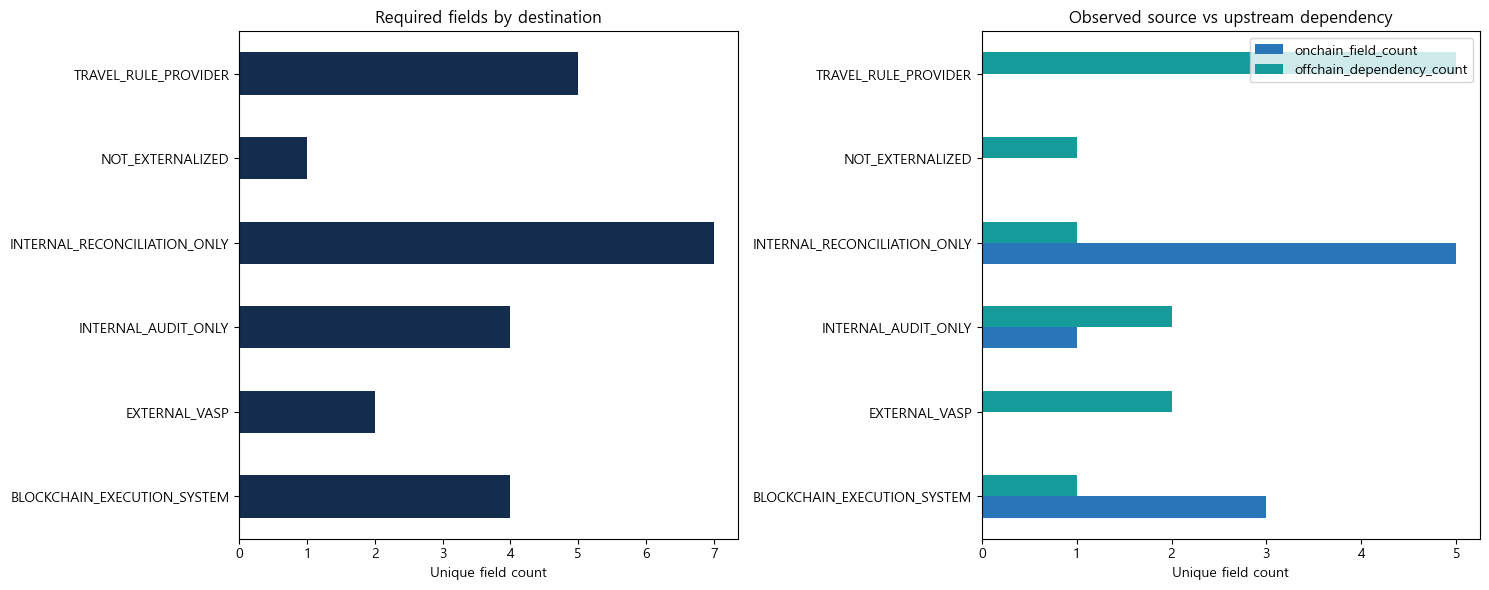

In [5]:
# 05. 한글 폰트 탐색 및 기존 navy/blue/teal 스타일
available_fonts = {font.name for font in font_manager.fontManager.ttflist}
korean_font = next((name for name in [
    'Malgun Gothic', 'NanumGothic', 'Noto Sans CJK KR', 'AppleGothic'
] if name in available_fonts), None)
plt.rcParams['font.family'] = korean_font or 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False
print({'korean_font': korean_font, 'fallback': 'English plot labels'})
colors = ['#142D4E', '#2876B8', '#159C9A']
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
destination_summary.plot.barh(
    x='destination', y='unique_required_field_count', color=colors[0],
    legend=False, ax=axes[0], title='Required fields by destination'
)
destination_summary.plot.barh(
    x='destination', y=['onchain_field_count', 'offchain_dependency_count'],
    color=colors[1:], ax=axes[1], title='Observed source vs upstream dependency'
)
for ax in axes:
    ax.set_ylabel('')
    ax.set_xlabel('Unique field count')
fig.tight_layout()
plt.show()

## 핵심 실험: Destination-specific Payload

공정한 baseline은 `EXTERNALIZABLE_SUPERSET`: 최소 하나의 외부 Destination이 허용하는
Field union이다. OMIT/NOT_EXTERNALIZED/Internal-only/POST internal trace-only는 제외한다.
Baseline은 비교용 Field 집합이며 실제 전송됐다고 주장하지 않는다.
Destination+phase별 required/allowed를 출력하며 내부 OMIT 값은 audit에도 원값을 싣지 않는다.
필요한 internal status reference의 wire naming은 BE 담당이다.

Provider-specific key/nesting/IVMS schema는 정의하지 않는다. MINIMIZE와
MAP_TO_EXTERNAL_SCHEMA의 실제 wire 구현은 CONTRACT_GAP이다.
Field retention 100%는 집합 연산 결과이며 off-chain 데이터 coverage 100%가 아니다.

,destination,runtime_phase,allowed_fields,required_fields,internal_only_fields,required_input_fields,omitted_fields,required_exact_fields,on_missing_action,transform_by_field,requirement_ids,wire_schema_status
0,BLOCKCHAIN_EXECUTION_SYSTEM,PRE_EXECUTION,"[amount, asset, beneficiary_address, originato...","[amount, asset, beneficiary_address, originato...",[kyc_status],"[amount, asset, beneficiary_address, originato...",[],"[amount, asset, beneficiary_address, originato...","{'amount': ['BLOCK'], 'asset': ['BLOCK'], 'ben...","{'amount': ['PASS_THROUGH'], 'asset': ['PASS_T...","[OR-DA-013, OR-DA-014, OR-DA-015, OR-DA-016]",CONTRACT_GAP
1,EXTERNAL_VASP,PRE_EXECUTION,"[beneficiary_identity, originator_identity]","[beneficiary_identity, originator_identity]",[kyc_status],"[beneficiary_identity, originator_identity]",[],[],"{'beneficiary_identity': ['REVIEW'], 'originat...","{'beneficiary_identity': ['MINIMIZE'], 'origin...","[OR-DA-004, OR-DA-005, OR-DA-008, OR-DA-009]",CONTRACT_GAP
2,INTERNAL_AUDIT_ONLY,POST_EXECUTION,"[execution_status, timestamp]","[execution_status, timestamp]",[kyc_status],"[execution_status, timestamp]",[],"[execution_status, timestamp]","{'execution_status': ['BLOCK', 'REVIEW'], 'tim...","{'execution_status': ['PASS_THROUGH'], 'timest...","[OR-DA-007, OR-DA-011, OR-DA-012, OR-DA-018]",INTERNAL_FIELD_PROFILE_ONLY
3,INTERNAL_AUDIT_ONLY,PRE_EXECUTION,[counterparty_vasp],[counterparty_vasp],[kyc_status],"[counterparty_vasp, kyc_status]",[kyc_status],[],"{'counterparty_vasp': ['REVIEW'], 'kyc_status'...",{'counterparty_vasp': ['FORMAT_NORMALIZE']},"[OR-DA-001, OR-DA-002, OR-DA-003]",INTERNAL_FIELD_PROFILE_ONLY
4,INTERNAL_RECONCILIATION_ONLY,POST_EXECUTION,"[execution_status, timestamp, tx_hash]","[execution_status, timestamp, tx_hash]",[kyc_status],"[execution_status, timestamp, tx_hash]",[],"[execution_status, timestamp, tx_hash]","{'execution_status': ['BLOCK', 'REVIEW'], 'tim...","{'execution_status': ['PASS_THROUGH'], 'timest...","[OR-DA-007, OR-DA-011, OR-DA-012, OR-DA-017, O...",INTERNAL_FIELD_PROFILE_ONLY
5,INTERNAL_RECONCILIATION_ONLY,PRE_EXECUTION,"[amount, beneficiary_address, originator_addre...","[amount, beneficiary_address, originator_addre...",[kyc_status],"[amount, beneficiary_address, originator_addre...",[],"[amount, beneficiary_address, originator_addre...","{'amount': ['BLOCK'], 'beneficiary_address': [...","{'amount': ['PASS_THROUGH'], 'beneficiary_addr...","[OR-DA-006, OR-DA-010, OR-DA-014, OR-DA-015, O...",INTERNAL_FIELD_PROFILE_ONLY
6,NOT_EXTERNALIZED,PRE_EXECUTION,[],[],[kyc_status],[kyc_status],[kyc_status],[],{'kyc_status': ['REVIEW']},{},"[OR-DA-002, OR-DA-003]",INTERNAL_FIELD_PROFILE_ONLY
7,TRAVEL_RULE_PROVIDER,PRE_EXECUTION,"[asset, beneficiary_identity, counterparty_vas...","[asset, beneficiary_identity, counterparty_vas...",[kyc_status],"[asset, beneficiary_identity, counterparty_vas...",[],"[asset, transaction_id]","{'asset': ['BLOCK'], 'beneficiary_identity': [...","{'asset': ['PASS_THROUGH'], 'beneficiary_ident...","[OR-DA-001, OR-DA-004, OR-DA-005, OR-DA-006, O...",CONTRACT_GAP


,destination,externalizable_superset_field_count,destination_payload_field_count,unnecessary_external_field_count_in_superset,unnecessary_external_field_count_in_profile,absolute_field_reduction,relative_exposure_reduction_pct,required_field_retention_pct,retention_scope
0,BLOCKCHAIN_EXECUTION_SYSTEM,8,4,4,0,4,50.0,100.0,CONTRACT_FIELD_SET_NOT_OBSERVED_VALUES_OR_WIRE...
1,EXTERNAL_VASP,8,2,6,0,6,75.0,100.0,CONTRACT_FIELD_SET_NOT_OBSERVED_VALUES_OR_WIRE...
2,TRAVEL_RULE_PROVIDER,8,5,3,0,3,37.5,100.0,CONTRACT_FIELD_SET_NOT_OBSERVED_VALUES_OR_WIRE...


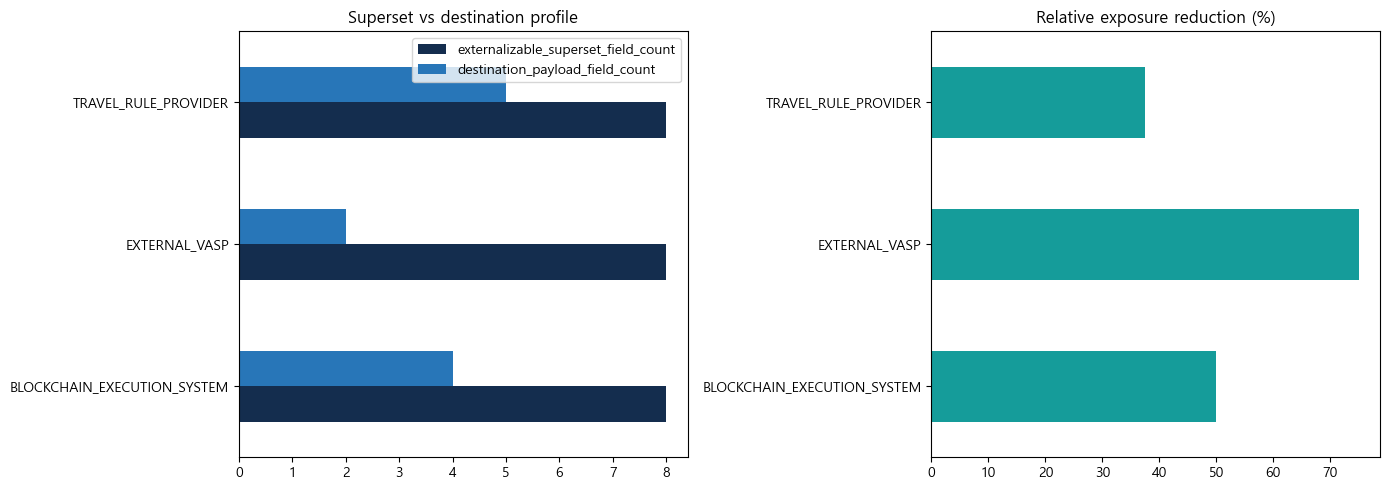

In [6]:
# 06. Field-level profile와 설계 효과크기
display(pd.DataFrame(result['destination_profiles']))
exposure = pd.DataFrame(result['exposure'])
display(exposure)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
exposure.plot.barh(
    x='destination',
    y=['externalizable_superset_field_count', 'destination_payload_field_count'],
    color=colors[:2], ax=axes[0], title='Superset vs destination profile'
)
exposure.plot.barh(
    x='destination', y='relative_exposure_reduction_pct', color=colors[2],
    legend=False, ax=axes[1], title='Relative exposure reduction (%)'
)
for ax in axes:
    ax.set_ylabel('')
fig.tight_layout()
plt.show()

## Exact / Phase / Leakage Invariant 및 Negative Control

정상 contract에 대해 내부 유출·OMIT 유출·Exact 손실변환·POST→PRE 혼입을 계산한다.
`PASS_THROUGH != EXTERNALIZE`: 값 보존만으로 destination permission을 얻지 않는다.
정상 결과만 보고 끝내지 않고 A~I SIMULATION을 수행한다.
내부 필드 삽입, 필수값 누락, 손실변환, phase 혼입, 미지원 목적지, 값 변경,
목적지 무관 외부 필드, FLOAT amount, 잘못된 contract phase가 탐지돼야 한다.

SIMULATION의 기호 값은 실제 Identity/KYC/VASP/승인 데이터가 아니다.
정상 fixture PASS는 field-profile 검사에 한정되며 전체 Runtime PASS가 아니다.
실서비스는 별도의 approved/requested match, 신뢰성, trace, provider contract 검사가 필요하다.

In [7]:
# 07. 실제 contract와 SIMULATION 결과를 분리 출력
display(pd.DataFrame([result['invariants']]).T)
display(pd.DataFrame(result['negative_controls']))
assert not result['contract_violations']
assert all(row['detected_as_expected'] for row in result['negative_controls'])

,0
not_externalized_leakage,0
omit_externalized_rows,0
exact_lossy_rows,0
external_pre_payload_post_field_count,0
contract_violation_count,0
negative_control_failures,0
pass_through_internal_only_destination_rows,14


,case,evidence_type,expected_rule,detected_as_expected,scope,decision,issues
0,NORMAL_FIELD_PROFILE,SIMULATION,None,True,SIMULATION_FIELD_PROFILE,PASS,[]
1,A_INTERNAL_ONLY_LEAKAGE:kyc_status,SIMULATION,FORBIDDEN_OR_UNRELATED_FIELD,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'FORBIDDEN_OR_UNRELATED_FIELD', 'fie..."
2,B_REQUIRED_MISSING,SIMULATION,REQUIRED_PAYLOAD_MISSING,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'REQUIRED_PAYLOAD_MISSING', 'field':..."
3,C_EXACT_LOSSY_TRANSFORM,SIMULATION,EXACT_OR_TRANSFORM_VIOLATION,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'EXACT_OR_TRANSFORM_VIOLATION', 'fie..."
4,D_POST_IN_PRE,SIMULATION,POST_EXECUTION_IN_PRE_EXECUTION,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'FORBIDDEN_OR_UNRELATED_FIELD', 'fie..."
5,E_UNSUPPORTED_DESTINATION,SIMULATION,UNSUPPORTED_DESTINATION_OR_PHASE,True,FIELD_PROFILE_ONLY,REVIEW,[{'rule': 'UNSUPPORTED_DESTINATION_OR_PHASE'}]
6,F_EXACT_VALUE_MUTATED,SIMULATION,EXACT_VALUE_MISMATCH,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'EXACT_VALUE_MISMATCH', 'field': 'am..."
7,G_UNRELATED_EXTERNAL_FIELD,SIMULATION,FORBIDDEN_OR_UNRELATED_FIELD,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'FORBIDDEN_OR_UNRELATED_FIELD', 'fie..."
8,H_FLOAT_AMOUNT,SIMULATION,NON_EXACT_AMOUNT_REPRESENTATION,True,SIMULATION_FIELD_PROFILE,BLOCK,"[{'rule': 'EXACT_VALUE_MISMATCH', 'field': 'am..."
9,I_CONTRACT_POST_REQUIREMENT_IN_PRE,SIMULATION,NaN,True,CONTRACT_VALIDATION,BLOCK,[{'assertion': 'execution_result_not_pre_execu...


## 통계설계 자기검수

- 검증 방식: 실제 표본 기술통계 + deterministic contract validation + Negative SIMULATION.
- 추정 대상: 현재 계약의 연결 완전성, Field availability, partition, invariant.
- 비교단위: 같은 외부 목적지의 superset/profile Field 집합. 표본추출 평균 비교가 아니다.
- 효과: Absolute Field Reduction, Relative Exposure Reduction, Required Field Retention.
- 추론통계: 무작위 처리/독립 반복 실험이 없으므로 t-test/ANOVA/χ²/McNemar를 쓰지 않는다.
- 관측/Simulation: Master의 실제 결측·값과 fixture detector 성공을 분리했다.
- 일반화: Field 감소를 개인정보 위험 감소율이나 Provider 성능/실행 성공률로 일반화하지 않는다.
- off-chain 값을 synthetic으로 채워 실제 coverage라고 주장하지 않는다.

## FPG 설계 결론 및 BE Handoff

ApprovedTransaction → RegulatoryOutboundRequirement → RequiredFieldResolver →
Source/Availability Resolver → Approved-vs-Requested Validator → Exact Validator →
Transform/Field Separation → Destination Payload Builder → Outbound Decision →
External Execution → POST_EXECUTION Result Binding → Trace/Reconciliation.

위 명칭은 기능 책임이며 새 BE API/DB field/enum 정의가 아니다. 현재 pipeline 순서를 재사용한다.
Destination Profile은 destination, allowed_fields, required_fields, internal_only_fields,
required_exact_fields, runtime_phase, on_missing_action을 가진 field-level 계약이다.
source 존재와 external payload 포함은 다르다. omitted input은 내부에서 존재만 검증한다.

BE는 required_field_presence, exact_preservation, transform_compatibility,
externalization_policy, phase_validation, destination_validation을 실행해야 한다.
필수 누락 시 현재 on_missing action을 보존하고 PASS를 금지한다.
Exact mismatch/금지 외부화/phase 위반은 BLOCK, 미지원/미해결 provider schema는 REVIEW다.
REVIEW_AFTER_HANDOFF는 원래 missing action이고 새 Decision enum이 아니다.

PASS는 현 outbound handoff 조건 충족이며 거래 승인·AML 적합·settlement 성공이 아니다.
REVIEW는 unresolved/unmapped/pending/ambiguous이며 KYC/AML 판정이 아니다.
FPG는 trusted upstream KYC result를 runtime policy input으로 소비하고 직접 생성하지 않는다.
KYC/AML/Sanctions/Customer Risk/VASP eligibility 및 Wallet/Signing/Custody/Finality는
외부 책임이다.

## 한계 및 CONTRACT_GAP

원천 재추출·Provider 송신·BE E2E는 실행하지 않았다. Master는 모두 사후 관측이므로
실행 전 승인값/정책/요청과의 실제 binding은 검증할 수 없다. value_lossless의 정수 문자열
유효성은 DA-02 원천 ground-truth exactness 재검증과 다르다.
generic transaction_id는 hash로 대체하지 않는다. contract의 실행 결과 phase를 보존한다.

In [8]:
# 08. Gap 및 재현 가능한 Artifact 생성
display(pd.DataFrame(result['contract_gaps']))
da04.export_artifacts(result, ROOT)
da04.export_artifacts(result, ROOT, check=True)
print('DA04_RESULT_JSON=' + da04.json.dumps(result, ensure_ascii=False, sort_keys=True))

,gap_id,status,detail,requirement_ids
0,APPROVAL_TRACE,CONTRACT_GAP,"Master contains POST_EXECUTION observations, n...",[]
1,ASSET_CONTEXT,CONTRACT_GAP,Native ETH context cannot identify every token...,[OR-DA-013]
2,EXECUTION_STATUS_MAPPING,CONTRACT_GAP,"receipt_status is evidence, not a contracted p...","[OR-DA-007, OR-DA-011, OR-DA-012]"
3,LEGAL_REVIEW,CONTRACT_GAP,Inherited candidate/review wording is retained...,"[OR-DA-003, OR-DA-006, OR-DA-012, OR-DA-013]"
4,PROVIDER_SCHEMA,CONTRACT_GAP,MINIMIZE/MAP_TO_EXTERNAL_SCHEMA provider wire ...,"[OR-DA-001, OR-DA-004, OR-DA-005, OR-DA-008, O..."
5,PROVIDER_WIRE_AND_E2E,CONTRACT_GAP,Field profiles do not establish provider accep...,[]
6,SOURCE_PROVENANCE,CONTRACT_GAP,No cloud re-extraction or original amount grou...,[]
7,TRANSACTION_ID_PHASE,CONTRACT_GAP,Legacy hash mapping cannot supply PRE_EXECUTIO...,"[OR-DA-006, OR-DA-010]"
8,UPSTREAM_INPUT,CONTRACT_GAP,Identity/KYC/VASP and approval inputs are abse...,"[OR-DA-001, OR-DA-002, OR-DA-003, OR-DA-004, O..."


DA04_RESULT_JSON={"contract_gaps": [{"detail": "Master contains POST_EXECUTION observations, not approval/request lineage.", "gap_id": "APPROVAL_TRACE", "requirement_ids": [], "status": "CONTRACT_GAP"}, {"detail": "Native ETH context cannot identify every token/approved asset or its scale.", "gap_id": "ASSET_CONTEXT", "requirement_ids": ["OR-DA-013"], "status": "CONTRACT_GAP"}, {"detail": "receipt_status is evidence, not a contracted provider/finality enum.", "gap_id": "EXECUTION_STATUS_MAPPING", "requirement_ids": ["OR-DA-007", "OR-DA-011", "OR-DA-012"], "status": "CONTRACT_GAP"}, {"detail": "Inherited candidate/review wording is retained; no new legal determination.", "gap_id": "LEGAL_REVIEW", "requirement_ids": ["OR-DA-003", "OR-DA-006", "OR-DA-012", "OR-DA-013"], "status": "CONTRACT_GAP"}, {"detail": "MINIMIZE/MAP_TO_EXTERNAL_SCHEMA provider wire schema is unresolved.", "gap_id": "PROVIDER_SCHEMA", "requirement_ids": ["OR-DA-001", "OR-DA-004", "OR-DA-005", "OR-DA-008", "OR-DA-009"]

## 논리 검수

| 기준 | 상태 | 확인 및 한계 |
|---|---|---|
| DA-01 Transaction ≠ Execution, Finality 외부 책임 | PASS | 실제 finality 판정 없음 |
| DA-02 FLOAT 금지·Exact/transform | PASS | value_lossless 문자열, 손실변환 탐지 |
| DA-03 PRE/POST 분리 | PASS | tx_hash/status/timestamp는 POST binding |
| DA-03 Approval→Request→Submission→Execution lineage | GAP | approval/request 없음 |
| foundation 04 중복 방지 | PASS | 기존 matrix/CSV를 입력으로 Runtime 검증 추가 |
| foundation 05 KYC/AML/VASP 책임 | PASS | upstream result만 소비 |
| vNext PASS_THROUGH ≠ EXTERNALIZE | PASS | internal destination pass-through 포함 |
| vNext PASS ≠ 승인, REVIEW ≠ KYC 판단 | PASS | field fixture PASS 범위 명시 |
| Destination/Exact/phase invariant | PASS | 정상 contract 및 negative control 실행 |
| Provider wire schema·legacy hash/승인 ID mapping | GAP | 임의 schema/값 생성 안 함 |

## 최종 요약
실제 Master 73,410건, 고유 hash 73,410개.
Requirement 18개 → Destination 6개 / Field 12개 / 정규화 row 35개.
안전한 표본 컬럼 매핑 5/12 (41.67%).
실행 전 off-chain 의존 6/12, POST_EXECUTION 의존 3/12.
to_address 결측 46건은 임의 보완하지 않는다.

| Destination | Superset | Payload | 감소 Field | 상대 감소율 | 필수 Field 유지율 |
|---|---:|---:|---:|---:|---:|
| BLOCKCHAIN_EXECUTION_SYSTEM | 8 | 4 | 4 | 50.00% | 100.00% |
| EXTERNAL_VASP | 8 | 2 | 6 | 75.00% | 100.00% |
| TRAVEL_RULE_PROVIDER | 8 | 5 | 3 | 37.50% | 100.00% |

기존 vNext contract 위반 0건. Negative SIMULATION 9/9 탐지.
CONTRACT_GAP 9종은 유지한다.
Field 집합 유지율은 실제 값 coverage·Provider wire 수용률이 아니다.
FPG는 목적지·phase·exact·누락을 검증하고, 미확정 정보를 생성하지 않는다.
Transaction Record != Execution Result; tx_hash != Final Settlement.
PASS_THROUGH != EXTERNALIZE. PASS는 거래 승인·AML 적합·Settlement 성공이 아니다.